In [1]:
import numpy as np
from libreria_trincee import calcola_tempo_reale
from libreria_trincee import Pendio,AbachiEfficienza,AbachiTemporali,AbacoPortate
from IPython.display import display, Markdown

# Notebook: esempio_progetto

### Introduzione e dati del problema

Il pendio oggetto di studio è interessato da un movimento franoso superficiale a cinematismo traslazionale, la cui superficie di scorrimento è stata individuata, sulla base delle risultanze descritte nella relazione geotecnica, alla profondità di $D = 5\,\text{m}$.

Il profilo stratigrafico mostra una coltre superficiale instabile, relativamente permeabile, appoggiata su un substrato di bassa permeabilità a una profondità $H=5$ m. In prima approssimazione, la situazione può essere modellata come un **pendio indefinito**, inclinato di $\beta = 14^\circ$, con **moto di filtrazione in condizioni stazionarie** e **superficie libera coincidente con il piano campagna**.

Si assume che le trincee drenanti progettate raggiungano il substrato impermeabile, con profondità $H_0 = 5\,\text{m}$, coincidente con quella del piano di scorrimento.

#### Analisi preliminare del coefficiente di sicurezza $F(Z)$

Per validare le condizioni progettuali, si procede preliminarmente allo studio del coefficiente di sicurezza in condizioni statiche. In particolare, si esegue un'analisi parametrica per valutare la sensibilità del coefficiente di sicurezza rispetto a:

- la profondità della falda: $d_w$;
- la coesione efficace $c'$;
- l'angolo di attrito efficace $\varphi'$.

Sulla base dei risultati di questa analisi, e delle risultanze sperimentali, sono stati selezionati i parametri rappresentativi da utilizzare per il dimensionamento del sistema drenante.


In [2]:
# Parametri geometrici e fisici
H = 5.0                 # Profondità dello strato impermeabile [m]
D = 5.0                 # Profondità del piano di scorrimento [m]
beta_deg = 14.0         # Inclinazione del pendio [°]
gamma = 19.0            # Peso specifico del terreno [kN/m³]
gamma_w = 9.81          # Peso specifico dell'acqua [kN/m³]
k_h = 6e-10              # Permeabilità orizzontale [m/s]
k_v = 6e-10              # Permeabilità verticale [m/s]
E = 2500.0              # Modulo di Young tangente [kPa]
nu = 0.25               # Coefficiente di Poisson [-]

# Parametri geotecnici per l'analisi F(Z)
c_med = 3.0             # Coesione media [kPa]
phi_med = 28.0          # Angolo di attrito medio [°]
c_min = 0.6 * c_med
c_max = 1.2 * c_med
phi_min = 0.8 * phi_med
phi_max = 1.2 * phi_med

# Profondità falda da analizzare
dw_values = [0.0, 2.5, 5.0]

# Condizione iniziale
c_zero = 0.0
phi_zero = phi_med
dw_zero = 0.0

# Dominio verticale
Z = np.linspace(0.5, H, 20) # (prof. iniziale > 0, prof.finale, n di punti)

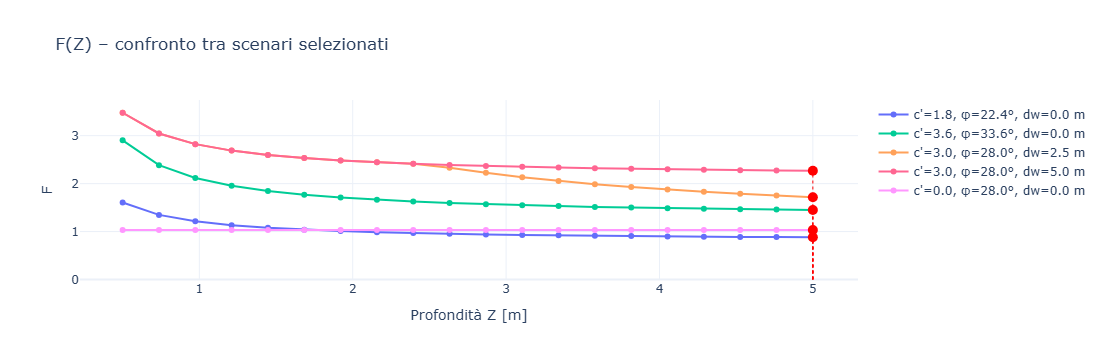

In [3]:
# Inizializzazione del pendio
pendio = Pendio(Z=Z, beta_deg=beta_deg, gamma=gamma, gamma_w=gamma_w, D=D)

# Calcolo delle curve F(Z)
dw_all = list(set(dw_values + [dw_zero]))
c_all = [c_min, c_med, c_max, c_zero]
phi_all = [phi_min, phi_med, phi_max]

F_dict = pendio.calcola_F(c_all, phi_all, dw_all)

# Curve da plottare nel grafico di sintesi
curve_rilevanti = [
    (c_min, phi_min, 0.0),
    (c_max, phi_max, 0.0),
    (c_med, phi_med, 2.5),
    (c_med, phi_med, 5.0),
    (c_zero, phi_med, 0.0)
]

# Plot delle curve selezionate
pendio.plot_confronto_F_vs_Z(F_dict, curve_rilevanti)


### Condizione iniziale e definizione degli obiettivi progettuali
Come evidenziato nel grafico di confronto delle curve $ F(Z) $, la combinazione geotecnica caratterizzata da $ c' = 0 \, \text{kPa} $ e $ \varphi' = 28^\circ $, in presenza di falda superficiale (ossia coincidente con il piano campagna), restituisce un valore del coefficiente di sicurezza costante con la profondità e prossimo all’unità. In questa configurazione, infatti, l’intero spessore della coltre superficiale di $ 5 \, \text{m} $ risulta instabile e potenzialmente mobilitabile.

Tale scenario è coerente con le osservazioni in sito, che indicano la possibilità di risalite piezometriche stagionali fino al piano campagna, e rispecchia adeguatamente il quadro stratigrafico emerso dalle indagini geotecniche. I valori adottati per $ c' $ e $ \varphi' $ sono da intendersi come **parametri rappresentativi medi** della coltre instabile, definiti a scala macroscopica e coerenti con le caratteristiche meccaniche del volume di terreno coinvolto nel cinematismo.

Considerata la corrispondenza tra i valori ottenuti per $ F(Z) $ e le evidenze geomorfologiche relative alla profondità della superficie di scorrimento, si ritiene appropriato adottare questa parametrizzazione come base per il dimensionamento del sistema di drenaggio.

Sulla base di questa configurazione iniziale, si procede a stimare i margini di miglioramento del coefficiente di sicurezza ottenibili attraverso il drenaggio, in relazione agli obiettivi progettuali, definiti come segue:

- **A regime**:
  $$
  F(t \to \infty) \geq 1.5
  $$

- **Entro 6 mesi dalla realizzazione delle trincee**:
  $$
  F(t = 6 \, \text{mesi}) \geq 1.2
  $$
  
### Calcolo del coefficiente di sicurezza iniziale ed Efficenca idraulica
A partire dalle curve già calcolate, è possibile stimare:

- il valore iniziale del coefficiente di sicurezza $F_0$, in assenza di coesione e con falda al piano campagna;
- il valore massimo ottenibile $ F_{\text{max}}$, in condizioni asciutte;
- la variazione massima ottenibile $ \Delta F_{\text{max}} = F_{\text{max}} - F_0 $;
- e, infine, l’efficienza idraulica media richiesta:

$$
E = \frac{F_{\text{target}} - F_0}{\Delta F_{\text{max}}}
$$

Tutti i valori di interesse sono calcolati sinteticamente mediante il metodo `calcolo_efficienza_progetto(...)` della classe `Pendio`, che restituisce direttamente $ F_0 $, $F_{\text{max}}$, $ \Delta F$, $ \Delta F_{\text{max}}$ ed $ E $, a partire dalle curve $ F(Z)$ già calcolate.


In [4]:
# === Parametri di progetto per la stima dell’efficienza ===
c_proj = 0.0           # coesione efficace [kPa]
phi_proj = 28.0        # angolo d’attrito efficace [°]
dw_init = 0.0          # falda iniziale (riva satura fino a Z)
dw_dry = 5.0           # condizione asciutta (falda a fondo pendio)

# Target di progetto
F_target = 1.5

# Calcolo sintetico dell’efficienza richiesta
F0, Fmax, deltaF, deltaFmax, E_target = pendio.calcolo_efficienza_progetto(
    F_dict,
    c_proj=c_proj,
    phi_proj=phi_proj,
    dw_init=dw_init,
    dw_dry=dw_dry,
    F_target=F_target
)

# Stampa dei risultati
display(Markdown("### 📌 **RISULTATI – Efficienza idraulica richiesta**"))
print(f"• F₀        (condizione iniziale)        = {F0:.3f}")
print(f"• Fmax      (pendio asciutto)            = {Fmax:.3f}")
print(f"• ΔF        (miglioramento richiesto)    = {deltaF:.3f}")
print(f"• ΔFmax     (miglioramento ottenibile)   = {deltaFmax:.3f}")
print(f"• F_target  (obiettivo di progetto)      = {F_target:.2f}")
print(f"• E         (efficienza idraulica media) = {E_target:.3f}")


### 📌 **RISULTATI – Efficienza idraulica richiesta**

• F₀        (condizione iniziale)        = 1.031
• Fmax      (pendio asciutto)            = 2.133
• ΔF        (miglioramento richiesto)    = 0.469
• ΔFmax     (miglioramento ottenibile)   = 1.101
• F_target  (obiettivo di progetto)      = 1.50
• E         (efficienza idraulica media) = 0.426


### Determinazione del rapporto S/H₀ tramite abaco di efficienza

A partire dal valore di efficienza idraulica media $ E_{\text{med}}$ richiesto, stimato nella sezione precedente, si procede ora all’interrogazione dell’abaco per determinare il rapporto $ S/H_0$ necessario.

In questa fase si assume una configurazione di riferimento con:
- punto di valutazione posto alla profondità della superficie di scorrimento, ossia $ d=D/H_0 = 1$;
- substrato impermeabile a profondità pari alla trincea, quindi $ n = H/H_0 = 1 $.

L’interrogazione dell’abaco fornisce il valore di $ S/H_0 $ compatibile con l’efficienza idraulica media richiesta, da cui si ricava direttamente l’interasse ottimale $S$ tra le trincee.

In [5]:
# Crea un'istanza della classe
abachiE = AbachiEfficienza()

# Parametri del problema
H0 = D           # profondità trincea
E_target = 0.44  # efficienza desiderata

# Etichette della configurazione
n_label = 'n=1.0'
d_label = 'd=1.0'

# Plotta le curve dell'abaco
abachiE.plot_abaco_risultati(E_target=E_target, n_label=n_label)

# Calcola Su/H0 con interpolazione
SuH0 = abachiE.ricava_SuH0_per_efficienza(E_target, n_label, d_label)

# Calcolo interasse
S = SuH0 * H0

# Dimensionamento trincee
display(Markdown("### 📌 **RISULTATI – Dimensionamento trincee**"))
print(f"• Rapporto S/H₀ richiesto: {SuH0:.2f}")
print(f"• Interasse ottimale delle trincee: S = {S:.2f} m")

### 📌 **RISULTATI – Dimensionamento trincee**

• Rapporto S/H₀ richiesto: 2.80
• Interasse ottimale delle trincee: S = 13.98 m


### Verifica temporale

L'efficienza idraulica media richiesta $E_{med}$ è stata raggiunta nel tempo adimensionale $T$ ricavato dagli abachi temporali per la configurazione definita da:

- permeabilità verticale $k_v$
- rapporto geometrico $D/H_0 = 1$
- valore noto di $S/H_0$

Il tempo reale $t$ è stato calcolato come:

$$
t = T \cdot \frac{2(1+\nu)(1 - 2\nu)\gamma_w H_0^2}{E \cdot k_v}
$$

dove:
- $T$ è il tempo adimensionale ($T_{50}$ o $T_{90}$)
- $\gamma_w$ è il peso specifico dell’acqua
- $E$ è il modulo di Young tangente
- $\nu$ è il coefficiente di Poisson
- $H_0$ è la profondità del dreno

Il coefficiente di sicurezza al tempo $T$ è stato stimato mediante:

$$
F(T) = F_0 + E_{med}(T) \cdot \Delta F
$$

con:
- $F_0$: coefficiente iniziale (condizione satura)
- $\Delta F = F_{\text{max}} - F_0$: incremento massimo ottenibile a piena efficienza
- $E_{med}(T)$: efficienza idraulica al tempo considerato

Nel caso specifico:
- a $T_{50}$, si verifica la condizione di sicurezza a medio termine
- a $T_{90}$, si verifica il comportamento a regime, assumendo $E(T_{90}) \approx 0.9 \cdot \bar{E}$

Il tempo reale è riportato in mesi, giorni o ore a seconda dell’ordine di grandezza.


In [6]:
abachiT = AbachiTemporali()
abachiT.plot_abaco_risultati(SuH0, n_label=n_label, tipo='T50')

In [7]:
# === Calcolo T₅₀ e T₉₀ adimensionali ===
T50 = abachiT.ricava_T_da_SuH0(SuH0, tipo='T50', n_label=n_label, d_label=d_label)
T90 = abachiT.ricava_T_da_SuH0(SuH0, tipo='T90', n_label=n_label, d_label=d_label)

# === Calcolo tempi reali ===
t50_reale = calcola_tempo_reale(
    T_adim=T50,
    H0=D,
    kv=k_v,
    gamma_w=gamma_w,
    E=E,
    nu=nu
)

t90_reale = calcola_tempo_reale(
    T_adim=T90,
    H0=D,
    kv=k_v,
    gamma_w=gamma_w,
    E=E,
    nu=nu
)

# === Calcolo coefficiente di sicurezza a T₅₀ ===
F_T50 = F0 + 0.5 * E_target * deltaFmax
# === Calcolo coefficiente di sicurezza a T₉₀ ===
F_T90 = F0 + E_target * deltaFmax

# Verifica temporale
display(Markdown("### 📌 **RISULTATI – Verifica temporale (T₅₀ / T₉₀)**"))
print(f"• T₅₀ per S/H₀ = {SuH0:.2f}, {n_label}, {d_label} → T = {T50:.4f}")
print(f"• T₉₀ per S/H₀ = {SuH0:.2f}, {n_label}, {d_label} → T = {T90:.4f}")
print(f"• T₅₀ reale: {t50_reale}")
print(f"• T₉₀ reale: {t90_reale}")
print(f"• Efficienza a T₅₀ (intermedia): E = {0.5 * E_target:.3f}")
print(f"• F(T₅₀) (coeff. sicurezza intermedio): {F_T50:.3f}")
print(f"• Efficienza a T₉₀ (regime): E = {E_target:.3f}")
print(f"• F(T₉₀) (coeff. sicurezza a regime): {F_T90:.3f}")

### 📌 **RISULTATI – Verifica temporale (T₅₀ / T₉₀)**

• T₅₀ per S/H₀ = 2.80, n=1.0, d=1.0 → T = 0.0557
• T₉₀ per S/H₀ = 2.80, n=1.0, d=1.0 → T = 0.4694
• T₅₀ reale: 4.39 mesi
• T₉₀ reale: 37.01 mesi
• Efficienza a T₅₀ (intermedia): E = 0.220
• F(T₅₀) (coeff. sicurezza intermedio): 1.274
• Efficienza a T₉₀ (regime): E = 0.440
• F(T₉₀) (coeff. sicurezza a regime): 1.516


### Portata drenata

Per stimare la portata drenata da ciascun ramo di trincea, si parte dalla valutazione del **fattore di portata adimensionale** $q$, ottenuto in funzione del parametro:

$$
s = \frac{S^*}{2D}
$$

dove:
- $S^*$ è l’interasse **effettivo** tra le trincee, corretto per l’anisotropia:
  
  $$
  S^* = S \cdot \sqrt{\frac{k_v}{k_h}}
  $$
  
- $D$ è la profondità del piano di scorrimento
- $k_v$, $k_h$ sono le permeabilità verticale e orizzontale

Una volta determinato $q$ dall’**abaco della portata**, la **portata specifica reale** per unità di lunghezza ($Q$) viene calcolata secondo:

$$
Q = q \cdot D \cdot k_h \quad \text{[m}^3/\text{s per metro]}
$$

Il valore è poi convertito in litri al secondo (l/s) per una lettura più intuitiva.

La **portata complessiva** per ciascun ramo di trincea (di lunghezza $L$) si ottiene come:

$$
Q_{\text{ramo}} = Q \cdot L
$$

ed è infine convertita in litri/ora (l/h), che rappresenta una stima utile per valutazioni progettuali e di manutenzione.

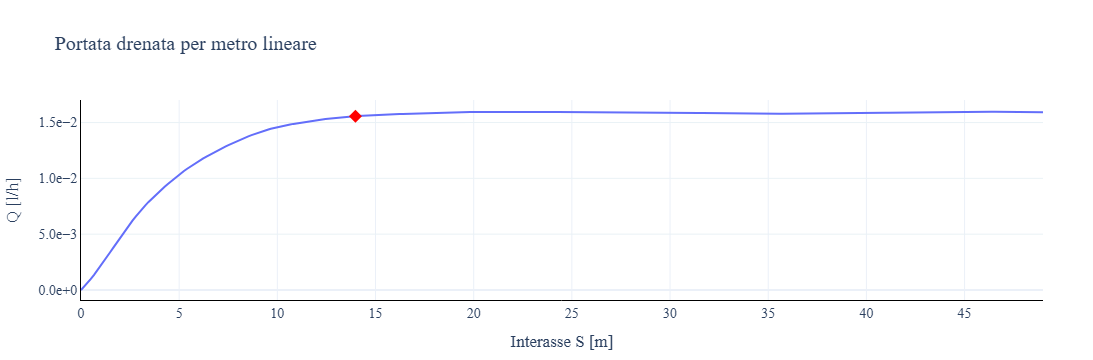

### 📌 **RISULTATI – Portata drenata**

• Portata per metro lineare: 1.5563e-02 l/h
• Portata da un ramo di 50 m: 7.7813e-01 l/h


In [8]:
# Calcolo della portata drenata per unità di lunghezza
abaco_q = AbacoPortate()
Q = abaco_q.calcola_portata(S=S, kv=k_v, kh=k_h, D=D)
# Data la portata per unità di lunghezza
L = 50  # m lunghezza di un ramo
Qd = Q * L

# Portata drenata
display(Markdown("### 📌 **RISULTATI – Portata drenata**"))
print(f"• Portata per metro lineare: {Q:.4e} l/h")
print(f"• Portata da un ramo di {L} m: {Qd:.4e} l/h")